In [1]:
import pandas as pd
import random
import time
import math
from collections import deque
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')
df.to_csv("dataset.csv", index=False)

print(df.head())
print(df.columns)
print(df.shape)

print('columns:', df.columns.tolist())
print('dtypes:')
print(df.dtypes)
print('\ntrack_id sample values:')
print(df['track_id'].head(20).tolist())
print('\nfirst 20 rows:')
print(df.head(20).to_string(index=False))

   Unnamed: 0                track_id                             artists  \
0       49667  7mBT5X016ptZbivwbzz4Xn                        Max Enforcer   
1       77158  4IhpTG2Kdtw6naxkkWoPer                         Exaltasamba   
2       42746  2YQa7y1HQLCXF9IJrLAKmr                       Magrudergrind   
3       77907  3nHLT73chRiCkoYhKOq43A            Péricles;Hellen Caroline   
4       89593  7InaXrvag0nYTncPA1Iitl  Juan Magán;Belinda;Lapiz Conciente   

                        album_name         track_name  popularity  \
0  DEDIQATED - 20 Years Of Q-dance               Gold          21   
1          Todos Os Sambas Ao Vivo  A Carta - Ao Vivo          51   
2  Magrudergrind & Shitstorm Split   Siphon Then Slit          11   
3                  Feito Pra Durar        Dois Rivais          41   
4        Halloween 2022 Pop Vol. 4  Si No Te Quisiera           0   

   duration_ms  explicit  danceability  energy  ...  loudness  mode  \
0       326507     False         0.555   0.718  ...

In [20]:
search_key = "Unnamed: 0"

sorted_data = df.sort_values(by=search_key).to_dict("records")
keys = [row[search_key] for row in sorted_data]

def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

def binary_search(arr, target):
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

def jump_search(arr, target):
    n = len(arr)
    step = int(math.sqrt(n))
    prev = 0

    while prev < n and arr[min(step, n) - 1] < target:
        prev = step
        step += int(math.sqrt(n))

        if prev >= n:
            return -1

    while prev < min(step, n):
        if arr[prev] == target:
            return prev
        prev += 1

    return -1

def interpolation_search(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high and arr[low] <= target <= arr[high]:

        if arr[high] == arr[low]:
            if arr[low] == target:
                return low
            return -1

        pos = low + (
            (target - arr[low]) * (high - low)
            // (arr[high] - arr[low])
        )

        if arr[pos] == target:
            return pos

        if arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1

def benchmark_search(search_fn, arr, target, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()
        search_fn(arr, target)
        end = time.perf_counter()

        times.append((end - start) * 1000)

    return sum(times) / len(times)

sizes = [1000, 10000, 50000, 100000]

results = {
    "Linear": [],
    "Binary": [],
    "Jump": [],
    "Interpolation": []
}

for n in sizes:
    subset = keys[:n]
    target = subset[-1]

    results["Linear"].append(
        benchmark_search(linear_search, subset, target)
    )

    results["Binary"].append(
        benchmark_search(binary_search, subset, target)
    )

    results["Jump"].append(
        benchmark_search(jump_search, subset, target)
    )

    results["Interpolation"].append(
        benchmark_search(interpolation_search, subset, target)
    )

for algo, times in results.items():
    print(algo)
    for n, t in zip(sizes, times):
        print(f"n={n}: {t:.4f} ms")
    print()


bad_input = [1, 2, 3, 4, 5, 1000000000]

target = 1000000000

start = time.perf_counter()
binary_search(bad_input, target)
end = time.perf_counter()

binary_time = (end - start) * 1000

start = time.perf_counter()
interpolation_search(bad_input, target)
end = time.perf_counter()

interpolation_time = (end - start) * 1000

print("Binary time:", binary_time)
print("Interpolation time:", interpolation_time)

# Interpoliacijos paieška įvertina ten, kur turėtų būti reikšmių pasiskirstymas, todėl, kai reikšmės yra itin netolygios, įvertinimas tampa netiksliu.

Linear
n=1000: 0.1150 ms
n=10000: 1.6476 ms
n=50000: 6.7452 ms
n=100000: 7.8470 ms

Binary
n=1000: 0.0060 ms
n=10000: 0.0075 ms
n=50000: 0.0072 ms
n=100000: 0.0098 ms

Jump
n=1000: 0.0274 ms
n=10000: 0.2039 ms
n=50000: 0.1875 ms
n=100000: 0.2344 ms

Interpolation
n=1000: 0.0030 ms
n=10000: 0.0029 ms
n=50000: 0.0025 ms
n=100000: 0.0032 ms

Binary time: 0.21660001948475838
Interpolation time: 0.35450002178549767


In [22]:
class BSTNode:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

class BinarySearchTree:
    def __init__(self):
        self.root = None
    def insert(self, key, value):
        self.root = self._insert(self.root, key, value)
    def _insert(self, node, key, value):
        if node is None:
            return BSTNode(key, value)

        if key < node.key:
            node.left = self._insert(node.left, key, value)
        elif key > node.key:
            node.right = self._insert(node.right, key, value)

        return node
    def search(self, key):
        return self._search(self.root, key)
    def _search(self, node, key):
        if node is None:
            return None

        if key == node.key:
            return node.value

        if key < node.key:
            return self._search(node.left, key)

        return self._search(node.right, key)
    def delete(self, key):
        self.root = self._delete(self.root, key)
    def _delete(self, node, key):
        if node is None:
            return node

        if key < node.key:
            node.left = self._delete(node.left, key)

        elif key > node.key:
            node.right = self._delete(node.right, key)

        else:
            if node.left is None and node.right is None:
                return None

            if node.left is None:
                return node.right

            if node.right is None:
                return node.left

            successor = self._min_value_node(node.right)
            node.key = successor.key
            node.value = successor.value
            node.right = self._delete(node.right, successor.key)

        return node
    def _min_value_node(self, node):
        current = node

        while current.left is not None:
            current = current.left

        return current
    
    def inorder(self):
        result = []
        self._inorder(self.root, result)
        return result
    def _inorder(self, node, result):
        if node:
            self._inorder(node.left, result)
            result.append(node.key)
            self._inorder(node.right, result)

    def preorder(self):
        result = []
        self._preorder(self.root, result)
        return result
    def _preorder(self, node, result):
        if node:
            result.append(node.key)
            self._preorder(node.left, result)
            self._preorder(node.right, result)

    def postorder(self):
        result = []
        self._postorder(self.root, result)
        return result
    def _postorder(self, node, result):
        if node:
            self._postorder(node.left, result)
            self._postorder(node.right, result)
            result.append(node.key)

    def bfs(self):
        if self.root is None:
            return []

        result = []
        queue = deque([self.root])

        while queue:
            node = queue.popleft()
            result.append(node.key)

            if node.left:
                queue.append(node.left)

            if node.right:
                queue.append(node.right)

        return result

    def range_query(self, low, high):
        result = []
        self._range_query(self.root, low, high, result)
        return result
    def _range_query(self, node, low, high, result):
        if node is None:
            return

        if low < node.key:
            self._range_query(node.left, low, high, result)

        if low <= node.key <= high:
            result.append(node.value)

        if node.key < high:
            self._range_query(node.right, low, high, result)

bst = BinarySearchTree()

data = df.to_dict("records")

for row in data:
    bst.insert(row["Unnamed: 0"], row)

low = 1000
high = 5000

subset = data[:50000]

bst = BinarySearchTree()

for row in subset:
    bst.insert(row["Unnamed: 0"], row)

start = time.perf_counter()
result_bst = bst.range_query(low, high)
end = time.perf_counter()

bst_time = (end - start) * 1000

start = time.perf_counter()
result_linear = [
    row for row in subset
    if low <= row["Unnamed: 0"] <= high
]
end = time.perf_counter()

linear_time = (end - start) * 1000

print("BST range query:", bst_time)
print("Linear baseline:", linear_time)
print("Result count:", len(result_bst))

BST range query: 2.1505000186152756
Linear baseline: 20.43269999558106
Result count: 1742


In [24]:
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, value):
        self.heap.append(value)
        self._heapify_up(len(self.heap) - 1)

    def peek(self):
        if not self.heap:
            return None
        return self.heap[0]

    def extract(self):
        if len(self.heap) == 0:
            return None

        if len(self.heap) == 1:
            return self.heap.pop()

        root = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._heapify_down(0)

        return root

    def replace_root(self, value):
        if not self.heap:
            self.insert(value)
            return

        self.heap[0] = value
        self._heapify_down(0)

    def _heapify_up(self, index):
        parent = (index - 1) // 2

        while index > 0 and self.heap[index][0] < self.heap[parent][0]:
            self.heap[index], self.heap[parent] = (
                self.heap[parent],
                self.heap[index]
            )

            index = parent
            parent = (index - 1) // 2

    def _heapify_down(self, index):
        smallest = index
        left = 2 * index + 1
        right = 2 * index + 2

        if left < len(self.heap) and self.heap[left][0] < self.heap[smallest][0]:
            smallest = left

        if right < len(self.heap) and self.heap[right][0] < self.heap[smallest][0]:
            smallest = right

        if smallest != index:
            self.heap[index], self.heap[smallest] = (
                self.heap[smallest],
                self.heap[index]
            )
            self._heapify_down(smallest)

top_k = 10
popular_heap = MinHeap()
rows = df.to_dict("records")

for row in rows:
    entry = (row["popularity"], row)
    if len(popular_heap.heap) < top_k:
        popular_heap.insert(entry)
    elif row["popularity"] > popular_heap.peek()[0]:
        popular_heap.replace_root(entry)

top_results = []
while popular_heap.peek() is not None:
    top_results.append(popular_heap.extract())

top_results.reverse()

print("Top 10 most popular tracks:")
for popularity, row in top_results:
    print(f"{popularity}: {row['track_name']} by {row['artists']}")

Top 10 most popular tracks:
98: La Bachata by Manuel Turizo
98: I'm Good (Blue) by David Guetta;Bebe Rexha
97: Tití Me Preguntó by Bad Bunny
96: Under The Influence by Chris Brown
96: I Ain't Worried by OneRepublic
94: Moscow Mule by Bad Bunny
94: Moscow Mule by Bad Bunny
94: Ojitos Lindos by Bad Bunny;Bomba Estéreo
93: Another Love by Tom Odell
93: PROVENZA by KAROL G


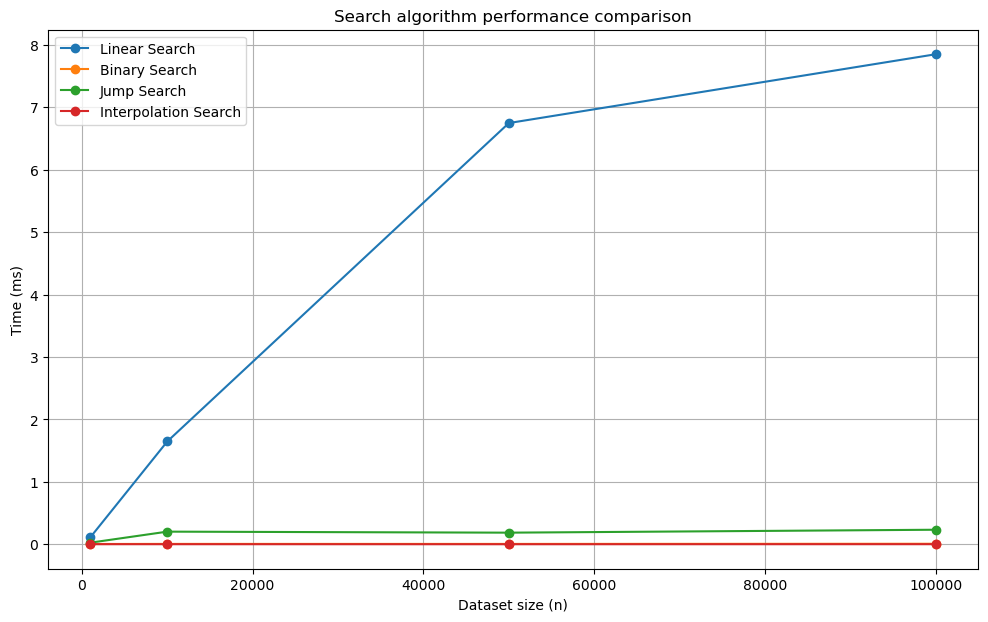

In [25]:
all_results = {
    "Linear Search": results["Linear"],
    "Binary Search": results["Binary"],
    "Jump Search": results["Jump"],
    "Interpolation Search": results["Interpolation"]
}

plt.figure(figsize=(12, 7))

for algorithm, times in all_results.items():
    plt.plot(
        sizes,
        times,
        marker="o",
        label=algorithm
    )

plt.xlabel("Dataset size (n)")
plt.ylabel("Time (ms)")
plt.title("Search algorithm performance comparison")
plt.legend()
plt.grid(True)

plt.show()